
# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [44]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง (ไม่มีข้อมูล)
raster_path = "example.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)


RasterioIOError: example.tif: No such file or directory


## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


In [ ]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


In [ ]:

import numpy as np

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()



## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [ ]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [ ]:

from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "boundary.shp"  # ใส่ path ของไฟล์ขอบเขต
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


**แบบฝึกหัด 1: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


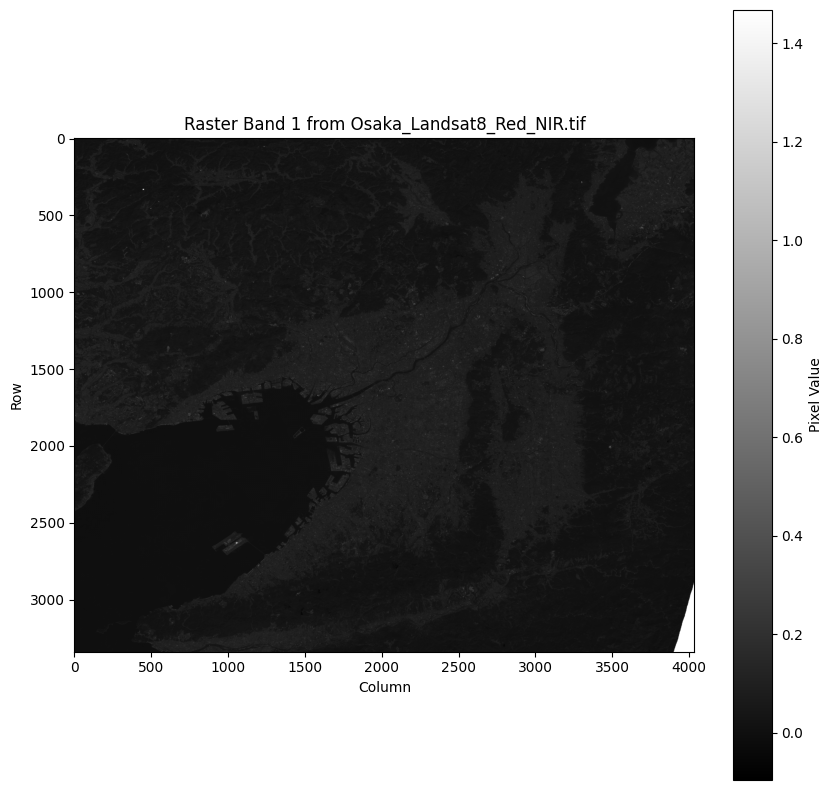

In [47]:
import rasterio
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# ใช้ raster_path ที่กำหนดไว้แล้วใน notebook
raster_path = '/content/drive/MyDrive/GEE_Output/Osaka_Landsat8_Red_NIR.tif'

try:
    with rasterio.open(raster_path) as dataset:
        # อ่าน Band 1 (หรือ Band อื่นๆ ที่ต้องการแสดง)
        band = dataset.read(1)

        # แสดงภาพ Raster
        plt.figure(figsize=(10, 10))
        plt.imshow(band, cmap='gray') # ใช้ cmap='gray' สำหรับภาพ band เดียว
        plt.colorbar(label='Pixel Value')
        plt.title(f'Raster Band 1 from {raster_path.split("/")[-1]}')
        plt.xlabel('Column')
        plt.ylabel('Row')
        plt.show()

except rasterio.errors.RasterioIOError:
    print(f"Error: Could not open or read the raster file at {raster_path}. Please ensure the file exists and the path is correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

**แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้**

In [48]:
import rasterio

raster_path = '/content/drive/MyDrive/GEE_Output/Osaka_Landsat8_Red_NIR.tif'

try:
    with rasterio.open(raster_path) as dataset:
        print("\n--- ข้อมูลเมตาของไฟล์ Raster ---")
        print(dataset.meta)

        print("\n--- คำอธิบายค่าเมตาที่สำคัญ ---")
        print(f"- Driver: {dataset.driver} - รูปแบบไฟล์ (เช่น 'GTiff')")
        print(f"- Width: {dataset.width} - จำนวนคอลัมน์ของพิกเซล")
        print(f"- Height: {dataset.height} - จำนวนแถวของพิกเซล")
        print(f"- Count: {dataset.count} - จำนวนแบนด์ (Band) ของภาพ")
        print(f"- CRS: {dataset.crs} - ระบบพิกัดอ้างอิง (Coordinate Reference System) เช่น EPSG:4326")
        print(f"- Transform: {dataset.transform} - Affine Transformation Matrix ที่ใช้อ้างอิงพิกเซลกับพิกัดจริง")
        print(f"- Dtype: {dataset.meta['dtype']} - ประเภทข้อมูลของพิกเซล (เช่น 'uint16', 'float32')")
        print(f"- Nodata: {dataset.nodata} - ค่าพิกเซลที่ถูกกำหนดให้เป็น 'ไม่มีข้อมูล' (No Data)")

except rasterio.errors.RasterioIOError:
    print(f"Error: Could not open or read the raster file at {raster_path}. Please ensure the file exists and the path is correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


--- ข้อมูลเมตาของไฟล์ Raster ---
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 4035, 'height': 3339, 'count': 2, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.00026949458523585647, 0.0, 134.9596543510941,
       0.0, -0.00026949458523585647, 35.1437108822671)}

--- คำอธิบายค่าเมตาที่สำคัญ ---
- Driver: GTiff - รูปแบบไฟล์ (เช่น 'GTiff')
- Width: 4035 - จำนวนคอลัมน์ของพิกเซล
- Height: 3339 - จำนวนแถวของพิกเซล
- Count: 2 - จำนวนแบนด์ (Band) ของภาพ
- CRS: EPSG:4326 - ระบบพิกัดอ้างอิง (Coordinate Reference System) เช่น EPSG:4326
- Transform: | 0.00, 0.00, 134.96|
| 0.00,-0.00, 35.14|
| 0.00, 0.00, 1.00| - Affine Transformation Matrix ที่ใช้อ้างอิงพิกเซลกับพิกัดจริง
- Dtype:

**แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่**

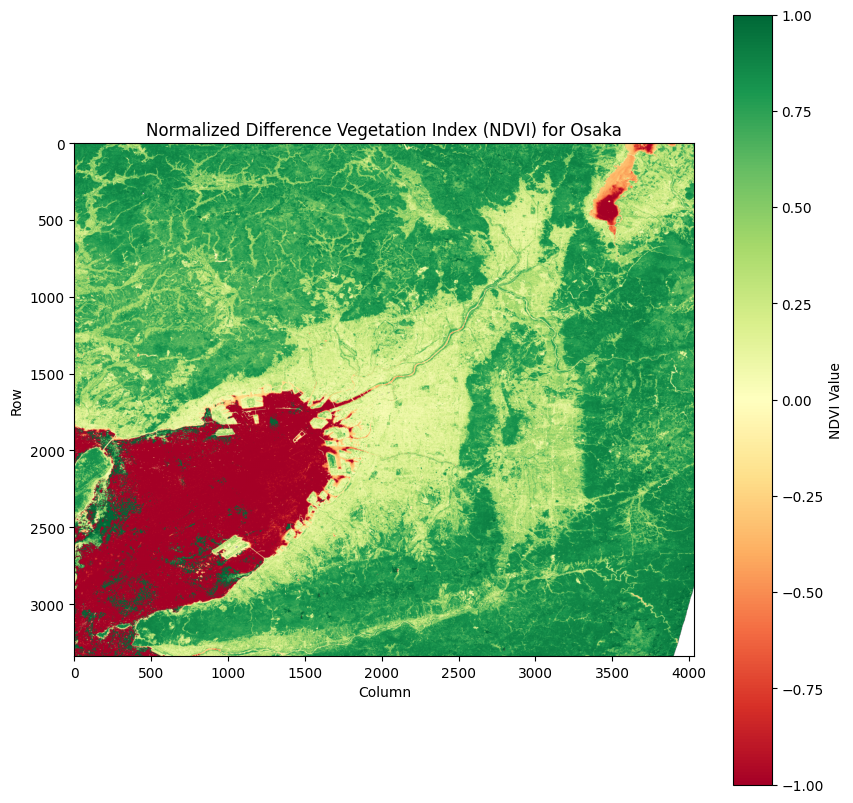

บันทึกไฟล์ NDVI เรียบร้อย!


In [55]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

raster_path = '/content/drive/MyDrive/GEE_Output/Osaka_Landsat8_Red_NIR.tif'

try:
    with rasterio.open(raster_path) as dataset:
        # อ่าน Band Red และ NIR
        # สมมติว่า Band 1 คือ Red และ Band 2 คือ NIR จากชื่อไฟล์ Osaka_Landsat8_Red_NIR.tif
        red = dataset.read(1).astype(float)  # Band 1 (Red)
        nir = dataset.read(2).astype(float)  # Band 2 (NIR)

    # หลีกเลี่ยงการหารด้วยศูนย์ โดยใช้ np.seterr(divide='ignore', invalid='ignore')
    # หรือเพิ่มค่าเล็กๆ ในส่วนส่วนร่วม (denominator)
    np.seterr(divide='ignore', invalid='ignore')
    ndvi = (nir - red) / (nir + red)
    np.seterr(divide='warn', invalid='warn') # รีเซ็ตการจัดการข้อผิดพลาดกลับสู่ค่าเริ่มต้น

    # แสดงผล NDVI
    plt.figure(figsize=(10, 10))
    plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1) # ใช้ RdYlGn สำหรับ NDVI
    plt.colorbar(label='NDVI Value')
    plt.title('Normalized Difference Vegetation Index (NDVI) for Osaka')
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.show()

except rasterio.errors.RasterioIOError:
    print(f"Error: Could not open or read the raster file at {raster_path}. Please ensure the file exists and the path is correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

    # บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")

**แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile**

กำลังแตกไฟล์ /content/drive/MyDrive/assignment/ge234/JPN_shp.zip ไปยัง /content/JPN_shp_extracted...
แตกไฟล์ Shapefile เรียบร้อย!
พบไฟล์ Shapefile: /content/JPN_shp_extracted/gadm41_JPN_1.shp
Columns in the GeoDataFrame: Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='object')
โหลดขอบเขตของจังหวัด Osaka สำเร็จ.
CRS ของ Shapefile และ Raster ตรงกัน
ตัดข้อมูล Raster สำเร็จ! บันทึกไฟล์ที่: clipped_osaka_by_shapefile.tif


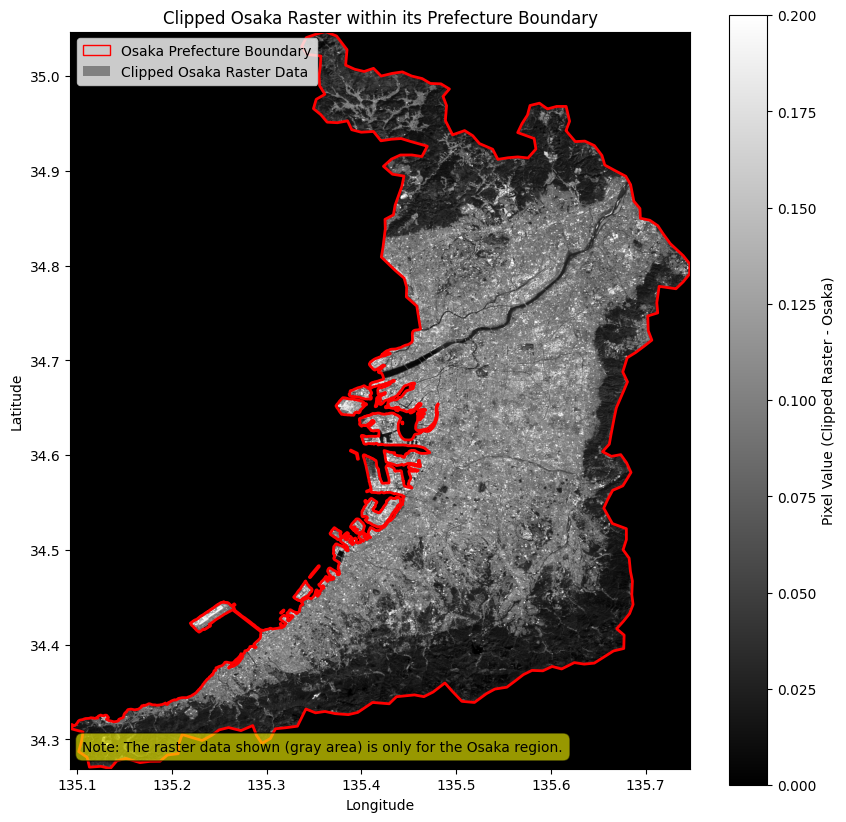

In [53]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import zipfile
import os
from rasterio.plot import plotting_extent #for proper georeferenced plotting
from matplotlib.patches import Patch #custom legend

# Path ไปยังไฟล์ Raster
raster_path = '/content/drive/MyDrive/GEE_Output/Osaka_Landsat8_Red_NIR.tif'

# ----------------------------------------------------------------------------
# ส่วนการจัดการ Shapefile จาก Google Drive (ZIP file)
# ----------------------------------------------------------------------------
zip_file_path = '/content/drive/MyDrive/assignment/ge234/JPN_shp.zip' # ข้อมูลจาก GADM

extraction_dir = '/content/JPN_shp_extracted'  # แตกไฟล์
os.makedirs(extraction_dir, exist_ok=True)

try:
    print(f"กำลังแตกไฟล์ {zip_file_path} ไปยัง {extraction_dir}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_dir)
    print("แตกไฟล์ Shapefile เรียบร้อย!")

    # ระบุไฟล์ .shp สำหรับระดับจังหวัด (gadm41_JPN_1.shp) และชื่อจังหวัดที่ต้องการ (Osaka)
    shapefile_name = os.path.join(extraction_dir, 'gadm41_JPN_1.shp') #ชั้นข้อมูล
    target_province_name = 'Osaka'

    if not os.path.exists(shapefile_name):
        raise FileNotFoundError(f"ไม่พบไฟล์ Shapefile ที่ต้องการ: {shapefile_name}")

    print(f"พบไฟล์ Shapefile: {shapefile_name}")

    # โหลดไฟล์ Shapefile ของขอบเขตจังหวัด
    gdf = gpd.read_file(shapefile_name)
    print("Columns in the GeoDataFrame:", gdf.columns)

    # Osaka ลองใช้ 'NAME_1'
    gdf_osaka = gdf[gdf['NAME_1'] == target_province_name] # Changed 'Name_1' to 'NAME_1'

    if gdf_osaka.empty:
        raise ValueError(f"ไม่พบจังหวัด '{target_province_name}' ในไฟล์ Shapefile หรือชื่อคอลัมน์ 'NAME_1' ไม่ถูกต้อง")

    print(f"โหลดขอบเขตของจังหวัด {target_province_name} สำเร็จ.")

    # ----------------------------------------------------------------------------
    # ส่วนที่เหลือเป็นการตัดข้อมูลภาพ Raster และบันทึกผลลัพธ์
    # ----------------------------------------------------------------------------

    # แปลง Polygon จาก GeoDataFrame ของ Osaka เป็นรูปแบบ GeoJSON ที่ rasterio.mask ต้องการ
    geometries = [mapping(geom) for geom in gdf_osaka.geometry]

    # เปิดไฟล์ Raster ต้นฉบับ
    with rasterio.open(raster_path) as src:
        # ตรวจสอบว่า CRS ของ Shapefile และ Raster ตรงกันหรือไม่ หากไม่ตรง ให้แปลง CRS ของ Shapefile
        if gdf_osaka.crs != src.crs:
            print(f"CRS ของ Shapefile ({gdf_osaka.crs}) ไม่ตรงกับ Raster ({src.crs}) กำลังแปลง CRS ของ Shapefile...")
            gdf_osaka_projected = gdf_osaka.to_crs(src.crs)
            geometries = [mapping(geom) for geom in gdf_osaka_projected.geometry]
            # For plotting, use the projected gdf_osaka
            gdf_to_plot = gdf_osaka_projected
        else:
            print("CRS ของ Shapefile และ Raster ตรงกัน")
            gdf_to_plot = gdf_osaka # Use original gdf_osaka for plotting if CRS matches

        # ตัดภาพ Raster ด้วยขอบเขตที่กำหนด (เฉพาะ Osaka)
        out_image, out_transform = mask(src, geometries, crop=True)
        out_meta = src.meta.copy()

        # อัปเดต Metadata สำหรับไฟล์ผลลัพธ์
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": src.nodata # ใช้ค่า nodata เดิมจาก source
        })

        # บันทึกไฟล์ที่ถูกตัด
        clipped_raster_path = f"clipped_{target_province_name.lower()}_by_shapefile.tif"
        with rasterio.open(clipped_raster_path, "w", **out_meta) as dest:
            dest.write(out_image)

        print(f"ตัดข้อมูล Raster สำเร็จ! บันทึกไฟล์ที่: {clipped_raster_path}")

        # Optional: แสดงภาพ Raster ที่ถูกตัดแล้ว พร้อมกับขอบเขตจังหวัด Osaka
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))

        # 1. แสดงขอบเขตจังหวัด Osaka (Shapefile) - เฉพาะกรอบ
        gdf_to_plot.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

        # 2. แสดงภาพ Raster ที่ถูกตัดแล้ว (เฉพาะพื้นที่ Osaka)
        display_band = out_image[0] if out_image.ndim == 3 else out_image

        # Plot raster using imshow with extent
        im = ax.imshow(display_band, cmap='gray', extent=plotting_extent(out_image[0], out_transform), vmin=0, vmax=0.2)
        fig.colorbar(im, ax=ax, label=f'Pixel Value (Clipped Raster - {target_province_name})')

        # Custom legend entries
        legend_elements = [
            Patch(facecolor='none', edgecolor='red', label=f'{target_province_name} Prefecture Boundary'),
            Patch(facecolor='gray', label=f'Clipped {target_province_name} Raster Data')
        ]
        ax.legend(handles=legend_elements, loc='upper left')

        ax.set_title(f'Clipped {target_province_name} Raster within its Prefecture Boundary')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        # Add an explanation about the raster data if needed
        ax.text(0.02, 0.02, "Note: The raster data shown (gray area) is only for the Osaka region.", # Changed from 0.98 to 0.02
                transform=ax.transAxes, fontsize=10, verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.6))

        plt.show()

except zipfile.BadZipFile:
    print(f"Error: ไฟล์ ZIP ที่ {zip_file_path} เสียหายหรือไม่ถูกต้อง")
except FileNotFoundError as fnf_error:
    print(f"Error: {fnf_error}. โปรดตรวจสอบว่าไฟล์ ZIP และ/หรือไฟล์ .shp อยู่ในเส้นทางที่ถูกต้อง")
except rasterio.errors.RasterioIOError:
    print(f"Error: ไม่สามารถเปิดหรืออ่านไฟล์ Raster ได้ที่ {raster_path}. โปรดตรวจสอบว่าไฟล์มีอยู่จริงและเส้นทางถูกต้อง")
except Exception as e:
    print(f"เกิดข้อผิดพลาดที่ไม่คาดคิด: {e}")